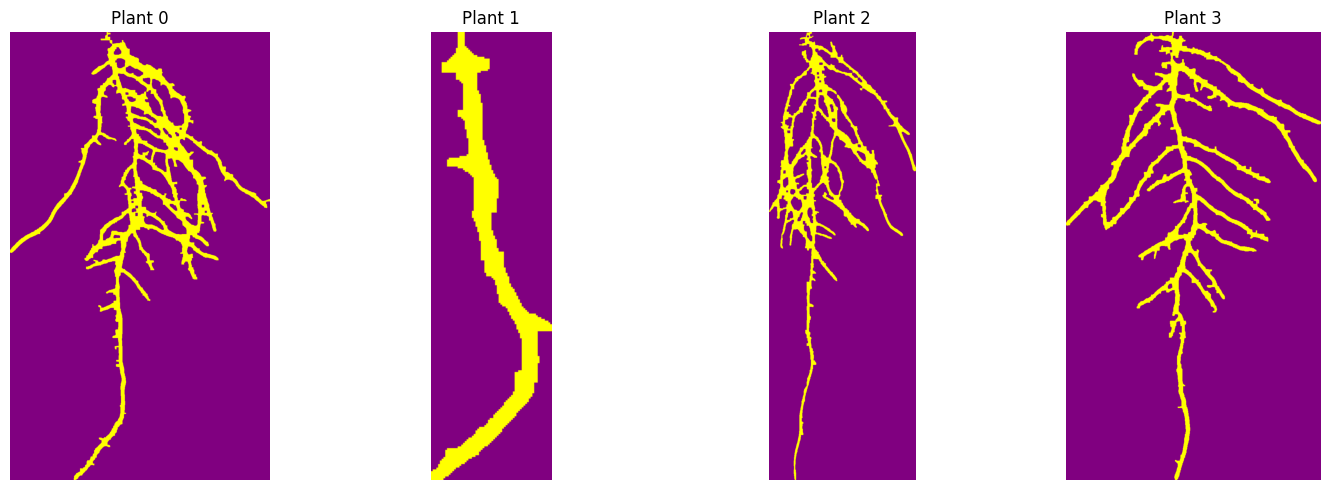

In [1]:
# Task 6: Root Segmentation and Visualization with Purple Background and Yellow Roots
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Step 1: Load the predicted mask from Task 5
predicted_mask_path = "task5_test_image_prediction_anastasiia_234301.png"  # Update file path as needed
binary_mask = cv2.imread(predicted_mask_path, cv2.IMREAD_GRAYSCALE)

# Ensure binary mask (convert any non-zero values to 255)
binary_mask[binary_mask > 0] = 255

# Step 2: Clean the mask using morphological operations
kernel = np.ones((4, 4), np.uint8)  # Define kernel for morphological operations
cleaned_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel, iterations=2)  # Close small gaps
cleaned_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_OPEN, kernel, iterations=1)  # Remove small noise

# Step 3: Identify connected components (roots) in the cleaned mask
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(cleaned_mask)

# Step 4: Filter connected components based on size and shape
min_root_area = 1500  # Minimum area to consider a region as a root
aspect_ratio_threshold = 1.7  # Minimum aspect ratio (length/width) for root structures
y_threshold = 100  # Exclude components too close to the top boundary

filtered_roots = []  # List to store masks for valid roots
for label_idx in range(1, num_labels):  # Skip background (label 0)
    x, y, w, h, area = stats[label_idx, cv2.CC_STAT_LEFT], stats[label_idx, cv2.CC_STAT_TOP], \
                       stats[label_idx, cv2.CC_STAT_WIDTH], stats[label_idx, cv2.CC_STAT_HEIGHT], \
                       stats[label_idx, cv2.CC_STAT_AREA]
    
    aspect_ratio = max(w, h) / min(w, h) if min(w, h) > 0 else 0  # Calculate aspect ratio
    
    if area >= min_root_area and aspect_ratio >= aspect_ratio_threshold and y > y_threshold:
        root_mask = np.zeros_like(binary_mask, dtype=np.uint8)
        root_mask[labels == label_idx] = 255
        filtered_roots.append(root_mask)

# Limit to 4 roots (since there are only 4 plants)
filtered_roots = filtered_roots[:4]

# Step 5: Visualize individual roots
fig, axes = plt.subplots(1, len(filtered_roots), figsize=(15, 5))  # Create a row of subplots
for i, root_mask in enumerate(filtered_roots):
    # Calculate the bounding box for the root to crop the visualization
    y_indices, x_indices = np.where(root_mask > 0)
    if len(y_indices) > 0 and len(x_indices) > 0:  # Ensure the root is not empty
        y_min, y_max = y_indices.min(), y_indices.max()
        x_min, x_max = x_indices.min(), x_indices.max()
        
        # Crop the root mask to its bounding box
        cropped_root = root_mask[y_min:y_max+1, x_min:x_max+1]
        
        # Convert the cropped root to a colored image
        colored_image = np.zeros((*cropped_root.shape, 3), dtype=np.uint8)  # Initialize RGB image
        colored_image[..., 0] = 128  # Set blue channel for purple background
        colored_image[..., 1] = 0    # Set green channel for purple background
        colored_image[..., 2] = 128  # Set red channel for purple background
        
        # Overlay yellow roots (set root pixels to yellow)
        root_indices = np.where(cropped_root > 0)
        colored_image[root_indices[0], root_indices[1], :] = [255, 255, 0]  # Yellow color for roots
        
        # Plot the colored root in the subplot
        axes[i].imshow(colored_image)
        axes[i].axis("off")  # Hide axes for a cleaner visualization
        axes[i].set_title(f"Plant {i}")  # Label each root by its index
    else:
        axes[i].axis("off")  # If no valid root, hide the subplot

plt.tight_layout()
plt.show()


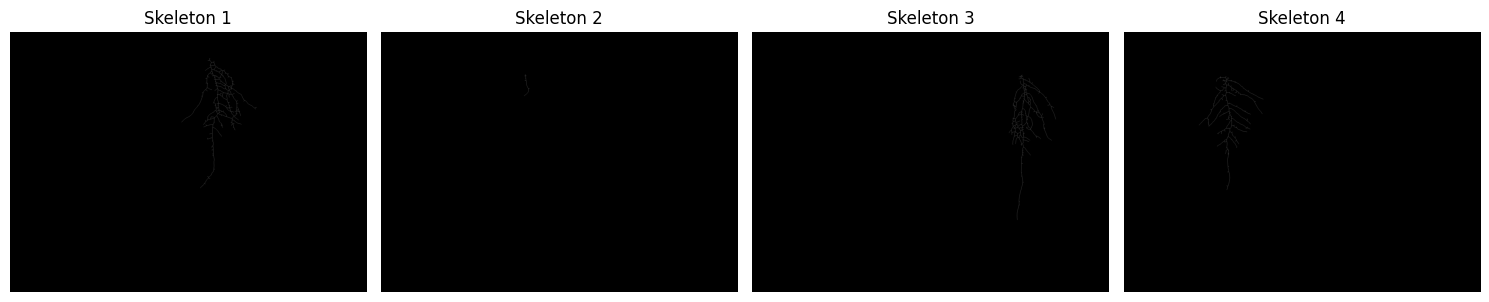

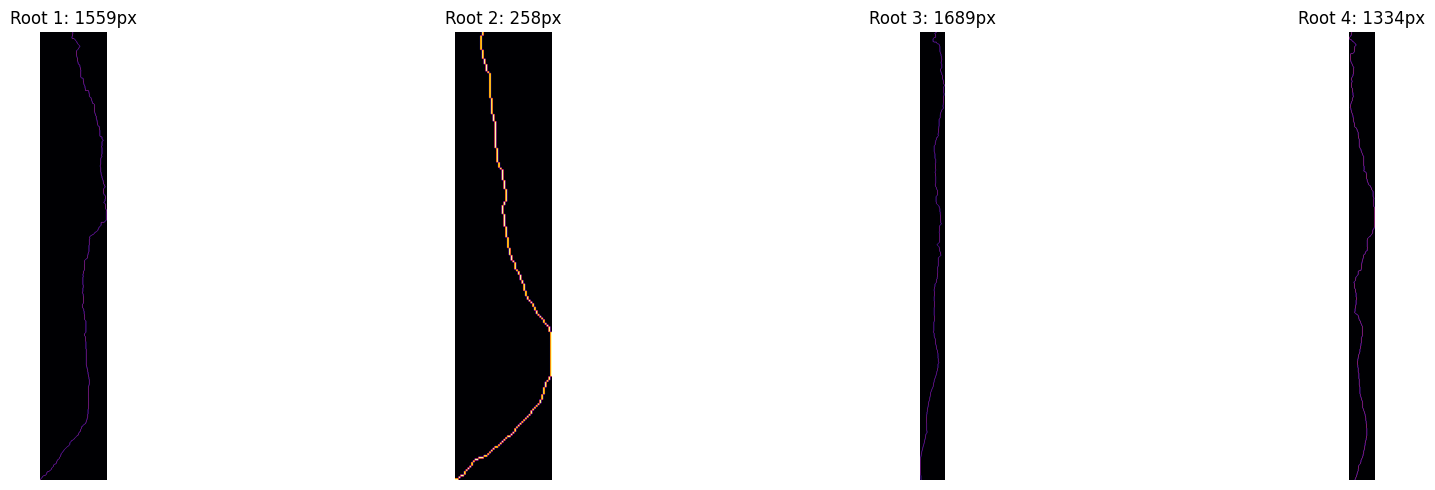

   Root Index  Primary Root Length (px) Start Coordinate End Coordinate
0           1                      1559      (316, 2298)   (1809, 2190)
1           2                       258      (498, 1662)    (748, 1647)
2           3                      1689      (506, 3112)   (2176, 3055)
3           4                      1334      (520, 1175)   (1830, 1184)


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from skimage.morphology import skeletonize
import pandas as pd

# Step 1: Skeletonize the root masks
skeletons = [skeletonize((root_mask > 0).astype(np.uint8)) for root_mask in filtered_roots]

# Visualize skeletons
fig, axes = plt.subplots(1, len(skeletons), figsize=(15, 5))
for i, skeleton in enumerate(skeletons):
    axes[i].imshow(skeleton, cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"Skeleton {i+1}")
plt.tight_layout()
plt.show()

# Step 2: Extract Root System Architecture
rsa_data = []
fig, axes = plt.subplots(1, len(skeletons), figsize=(20, 5))

for i, skeleton in enumerate(skeletons):
    coords = np.column_stack(np.nonzero(skeleton))
    if len(coords) == 0:
        print(f"Root {i + 1} contains no skeleton pixels.")
        continue

    # Create graph using coordinates
    G = nx.Graph()
    coord_to_node = {tuple(coord): idx for idx, coord in enumerate(coords)}
    for coord in coords:
        y, x = coord
        G.add_node(coord_to_node[tuple(coord)], coord=(y, x))
        for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]:
            neighbor = (y + dy, x + dx)
            if neighbor in coord_to_node:
                G.add_edge(coord_to_node[tuple(coord)], coord_to_node[neighbor])

    # Find the longest path
    start_node = min(G.nodes, key=lambda n: G.nodes[n]["coord"][0])
    lengths, paths = nx.single_source_dijkstra(G, start_node)
    end_node = max(lengths, key=lengths.get)

    primary_path = paths[end_node]
    primary_length = lengths[end_node]

    # Create mask for primary root
    primary_root_mask = np.zeros_like(skeleton, dtype=np.uint8)
    for node in primary_path:
        y, x = G.nodes[node]["coord"]
        primary_root_mask[y, x] = 255

    # Crop image dynamically to root size
    y_coords, x_coords = np.nonzero(primary_root_mask)
    if len(y_coords) > 0 and len(x_coords) > 0:
        cropped_mask = primary_root_mask[min(y_coords):max(y_coords)+1, min(x_coords):max(x_coords)+1]
    else:
        cropped_mask = primary_root_mask

    # Visualize primary root
    axes[i].imshow(cropped_mask, cmap="inferno")
    axes[i].set_title(f"Root {i+1}: {int(primary_length)}px")
    axes[i].axis("off")

    # Save RSA data
    rsa_data.append({
        "Root Index": i + 1,
        "Primary Root Length (px)": primary_length,
        "Start Coordinate": G.nodes[start_node]["coord"],
        "End Coordinate": G.nodes[end_node]["coord"],
    })

plt.tight_layout()
plt.show()

# Step 3: Display RSA data as a table
rsa_df = pd.DataFrame(rsa_data)
print(rsa_df)